In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import sys
from copy import deepcopy,copy
from datetime import datetime
import pickle
import sys
import matplotlib.pyplot as plt
import warnings
#warnings.filterwarnings("ignore")
#warnings.filterwarnings("ignore", category=RuntimeWarning)
stderr_fileno = sys.stderr
sys.stderr = open(os.devnull, 'w')

src = os.path.dirname('/export/home/oriolca/Integral_BMS_Governing_Equations/I-BMS/')
sys.path.append(src)
from mcmc_ode import *
from parallel_ode import *

path = os.path.join(src, "Prior/")
sys.path.append(path)
from fit_prior import read_prior_par

priors = {
    "v2_p3": f"Prior/final_prior_param_sq.named_equations.nv2.np3.2016-09-09 18:49:42.927679.dat",
    "v2_p4": f"Prior/final_prior_param_sq.named_equations.nv2.np4.2016-09-09 18:49:43.056910.dat",
    "v2_p8": f"Prior/final_prior_param_sq.named_equations.nv2.np8.2016-09-09 18:49:42.800618.dat",
    "v3_p8": f"Prior/final_prior_param_sq.named_equations.nv3.np6.maxs50.2021-12-14 09:51:44.438445.dat",
}

def rossler(t, state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    dxdt = -y-z
    dydt = x+a*y
    dzdt = b + z*(x-c)
    return [dxdt, dydt, dzdt]

# Parameters
t_span = (0, 100)
t_eval = np.linspace(*t_span, 10000)  # 10k points
x0 = [1.0, 1.0, 1.0]  # initial conditions

# Integrate the Lorenz system
sol = solve_ivp(rossler, t_span, x0, t_eval=t_eval, method='RK45', rtol=1e-9, atol=1e-9)

eps = 10 ** -(40 / 20)
# Convert to a pandas DataFrame for convenience
data = pd.DataFrame({'t': sol.t, 'x': sol.y[0] + eps * np.random.normal(scale=np.std(sol.y[0]), size=sol.y[0].shape),
                     'y': sol.y[1]+ eps * np.random.normal(scale=np.std(sol.y[1]), size=sol.y[1].shape),
                     'z': sol.y[2]+ eps * np.random.normal(scale=np.std(sol.y[2]), size=sol.y[2].shape)})

print(data)

x = data[['x','y','z']]
t = pd.Series(data[['t']].t)

dx = pd.DataFrame(data = {'x': np.gradient(data["x"],t), 'y': np.gradient(data["y"],t),'z': np.gradient(data["z"],t)})

print(x)

print(t)

print(dx)

               t         x         y         z
0       0.000000  0.922556  1.081739  1.005144
1       0.010001  0.955274  0.994119  0.971146
2       0.020002  0.912120  1.055109  0.932377
3       0.030003  0.986856  1.018544  0.895139
4       0.040004  0.912715  1.144240  0.829659
...          ...       ...       ...       ...
9995   99.959996  9.637021 -3.862570  0.718196
9996   99.969997  9.564723 -3.746117  0.686574
9997   99.979998  9.668145 -3.692304  0.758979
9998   99.989999  9.673086 -3.643895  0.774787
9999  100.000000  9.650968 -3.576730  0.815021

[10000 rows x 4 columns]
             x         y         z
0     0.922556  1.081739  1.005144
1     0.955274  0.994119  0.971146
2     0.912120  1.055109  0.932377
3     0.986856  1.018544  0.895139
4     0.912715  1.144240  0.829659
...        ...       ...       ...
9995  9.637021 -3.862570  0.718196
9996  9.564723 -3.746117  0.686574
9997  9.668145 -3.692304  0.758979
9998  9.673086 -3.643895  0.774787
9999  9.650968 -3.576730 

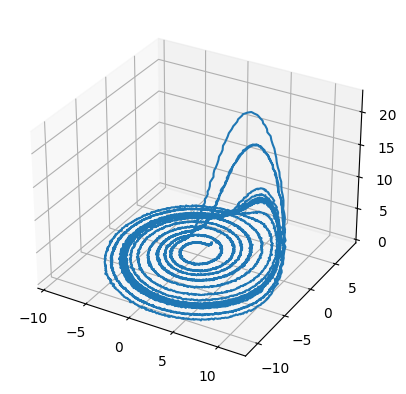

In [2]:
ax = plt.figure().add_subplot(projection='3d')
ax.plot(x['x'], x['y'], x['z'], label='parametric curve')

plt.show()

In [3]:
XLABS = ['x','y','z']
n_params = 8

path = os.path.join(src, priors[f"v{len(XLABS)}_p{str(n_params)}"])
prior_par = read_prior_par(path)

Ts=[1] + [1.04**k for k in range(1, 20)]

del prior_par['Nopi_abs']
del prior_par['Nopi2_abs']
del prior_par['Nopi_tan']
del prior_par['Nopi2_tan']
del prior_par['Nopi_sinh']
del prior_par['Nopi2_sinh']
del prior_par['Nopi_cosh']
del prior_par['Nopi2_cosh']
del prior_par['Nopi_tanh']
del prior_par['Nopi2_tanh']


OPS = {
    "sin": 1,
    "cos": 1,
    "exp": 1,
    "pow2": 1,
    "pow3": 1,
    "-": 1,
    "+": 2,
    "*": 2,
    "/": 2,
    "**": 2,
}
import time

start = time.time()
model_x = Tree(
    ops=OPS,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
    from_string = '(-y - z)'
)

print(model_x)
print(model_x.E)

model_y = Tree(
    ops=OPS,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
    from_string ='((x + (_a0_ * y))'
)
print(model_y)
print(model_y.E)

model_z = Tree(
    ops=OPS,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
    from_string ='(_a1_ + (z * (x - _a2_)))'
)
print(model_z)
print(model_z.E)

model_x.integrator=Integrator('rk45')
model_y.integrator=Integrator('rk45')
model_z.integrator=Integrator('rk45')
couplings=[model_x,model_y,model_z]
model_x.set_couplings(couplings)

print(model_x)
print(model_x.E)
print(model_x.par_values)
print(model_x.x0_values)

(-y - z)
152357.2887947769
(x + (_a0_ * y))
152368.2967821435
(_a1_ + (z * (x - _a2_)))
152376.48949504495
(-y - z)
19770.332032103892
<SharedDict {'d0': {'_a0_': 0.2017442366108275, '_a1_': 0.21345734449633574, '_a2_': 5.609598578151453, '_a3_': 1.0, '_a4_': 1.0, '_a5_': 1.0, '_a6_': 1.0, '_a7_': 1.0}}>
<SharedDict {'d0': array([0.978113  , 0.97309793, 0.99027153])}>


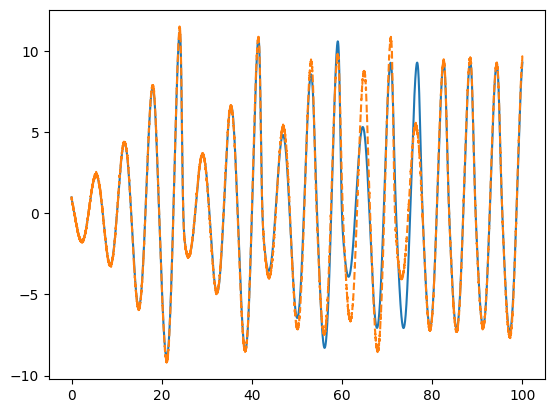

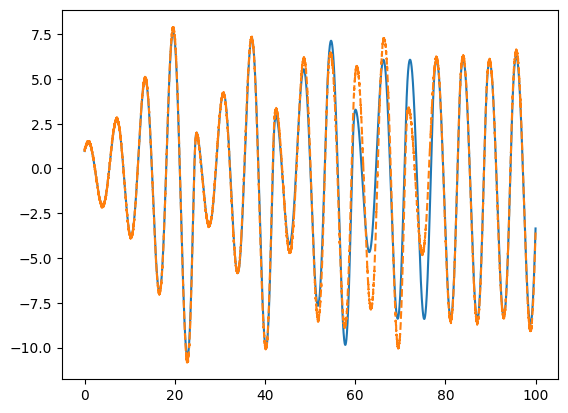

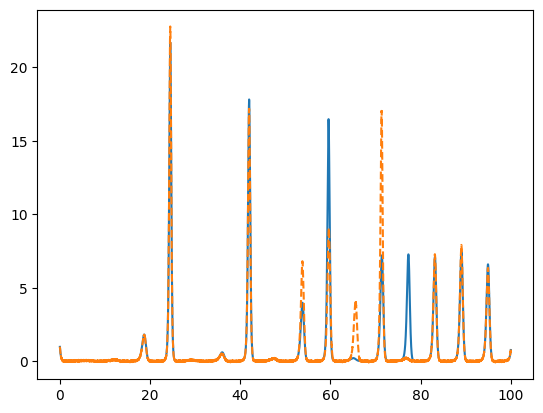

In [4]:
integral = model_x.integrate(t)

plt.plot(t,integral['d0']['x'])
plt.plot(t,x['x'],'--')
plt.show()
plt.plot(t,integral['d0']['y'])
plt.plot(t,x['y'],'--')
plt.show()
plt.plot(t,integral['d0']['z'])
plt.plot(t,x['z'],'--')
plt.show()

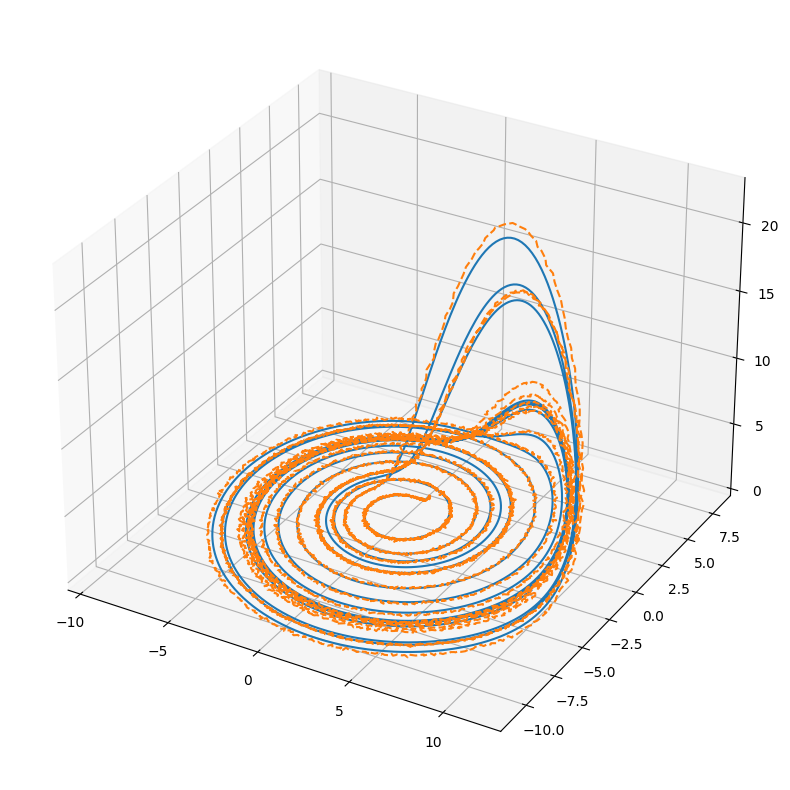

In [5]:
ax = plt.figure(figsize=(10,10)).add_subplot(projection='3d')
ax.plot(integral['d0']['x'], integral['d0']['y'], integral['d0']['z'], label='parametric curve')
ax.plot(x['x'], x['y'], x['z'],'--', label='parametric curve')

plt.show()

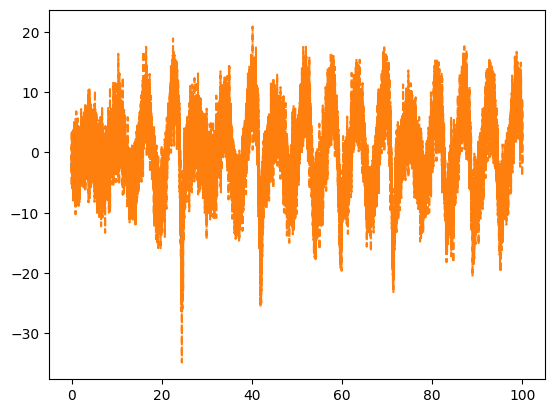

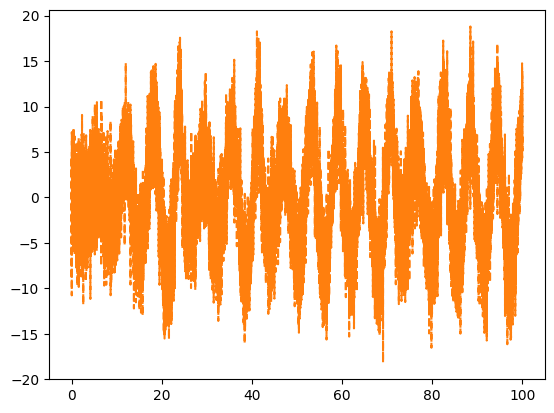

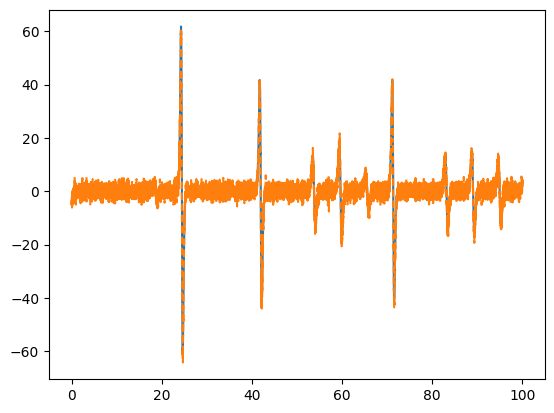

In [6]:
dx_pred = model_x.predict(x)

plt.plot(t,dx_pred['x'])
plt.plot(t,dx['x'],'--')
plt.show()
plt.plot(t,dx_pred['y'])
plt.plot(t,dx['y'],'--')
plt.show()
plt.plot(t,dx_pred['z'])
plt.plot(t,dx['z'],'--')
plt.show()